In [2]:
import pandas as pd

df = pd.read_csv("../../data/Clean_BNPParibas_Data.csv")

X_cluster = df.drop(columns=["contract_type", "customer_id"])
y = df["contract_type"]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X_cluster.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_cluster.select_dtypes(
    include=["object"]
).columns.tolist()

cluster_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_cluster_processed = cluster_preprocessor.fit_transform(X_cluster)

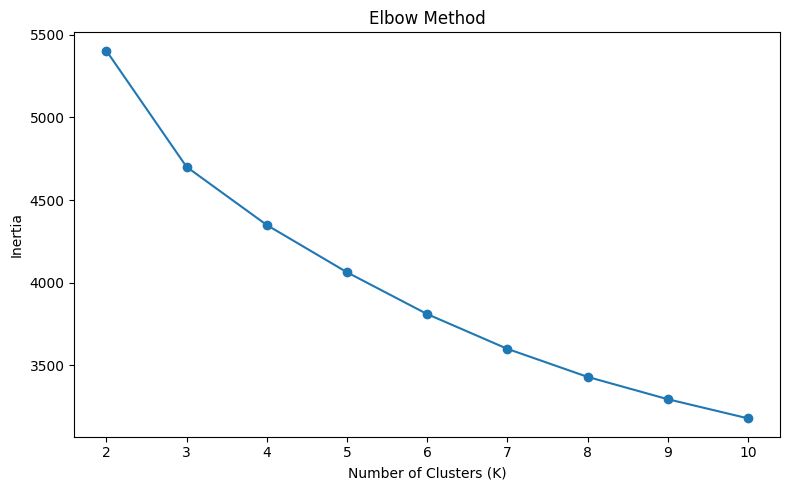

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_processed)

    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.tight_layout()
plt.show()

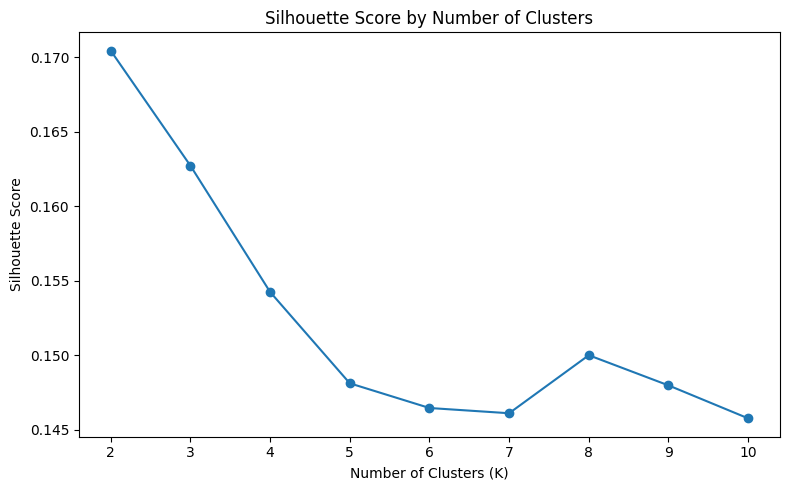

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster_processed)

    score = silhouette_score(X_cluster_processed,labels)

    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.tight_layout()
plt.show()

In [11]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    X_cluster_processed
)

In [17]:
clustered_df = df.copy()

clustered_df["Cluster"] = cluster_labels

cluster_names = {
    0: "Month-to-Month",
    1: "One Year",
    2: "Two Year"
}

clustered_df["Cluster_Name"] = (
    clustered_df["Cluster"]
    .map(cluster_names)
)

display(clustered_df.head())

,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,support_tickets,payment_method,churn,Cluster,Cluster_Name
0,1,56,15,59.23,929.62,Month-to-Month,Fiber,5,UPI,1,0,Month-to-Month
1,2,69,64,24.20,1613.60,Month-to-Month,Fiber,1,Credit Card,1,0,Month-to-Month
2,3,46,28,78.02,2053.63,One Year,Fiber,1,UPI,0,1,One Year
3,4,32,39,45.95,1688.47,Month-to-Month,Fiber,1,UPI,0,1,One Year
4,6,25,17,53.02,850.81,Two Year,DSL,0,Cash,0,1,One Year


In [19]:
cluster_summary = clustered_df.groupby("Cluster")[numeric_features].mean()

display(cluster_summary)

,age,tenure_months,monthly_charges,total_charges,support_tickets,churn
Cluster,,,,,,
0,44.093750,25.150568,77.104176,1655.575313,2.161932,1.00000
1,42.492013,31.974441,57.320927,1531.284633,1.661342,0.00000
2,45.060976,53.808943,112.134187,5891.090325,1.979675,0.45122


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster_processed)

In [25]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels
})

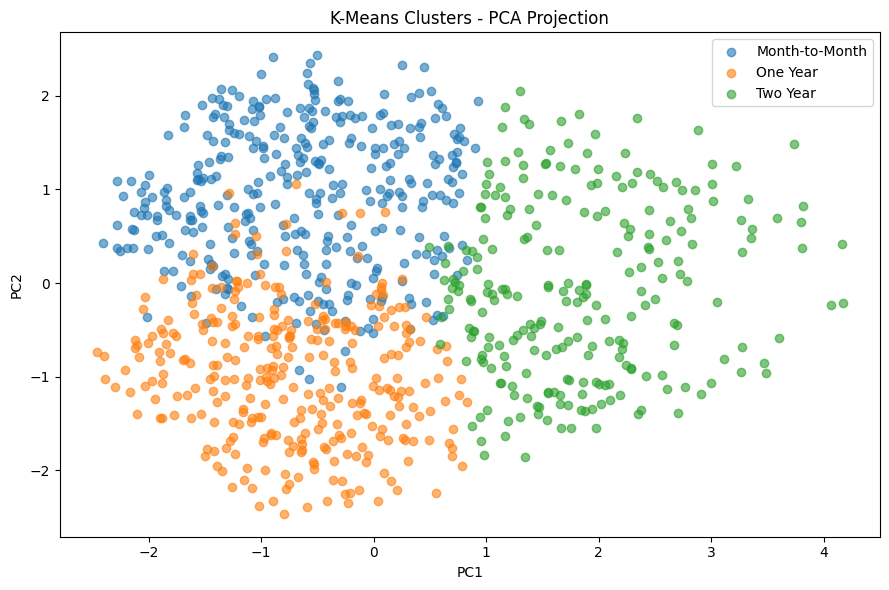

In [26]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["Cluster"].unique()):

    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=cluster_names[cluster],
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters - PCA Projection")
plt.legend()

plt.tight_layout()
plt.show()